# Phase 1 — Vérification visuelle du pipeline de préparation

Ce notebook ne redéfinit aucune logique : il appelle les fonctions de `src/preprocessing.py`
(déjà testées par `tests/test_preprocessing.py`) sur les vraies données FD001, et montre à quoi
ressemblent les données à chaque étape. Chaque figure est accompagnée d'une explication de ce
qu'elle montre et pourquoi elle valide (ou non) l'étape correspondante du pipeline.

In [1]:
import sys
sys.path.append("..")  # pour pouvoir importer src.preprocessing depuis notebooks/

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import add_piecewise_rul, compute_norm_stats, make_windows, normalize, select_features

DATA_DIR = "../DATA/CMaps"

INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

train = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
train = train.iloc[:, : len(COL_NAMES)]
train.columns = COL_NAMES
train.shape

(20631, 26)

In [2]:
selected_sensors = select_features(train, SENSOR_NAMES, std_threshold=1e-2)
dropped_sensors = [s for s in SENSOR_NAMES if s not in selected_sensors]

print(f"Capteurs gardés ({len(selected_sensors)}):", selected_sensors)
print(f"Capteurs exclus ({len(dropped_sensors)}):", dropped_sensors)

Capteurs gardés (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Capteurs exclus (7): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


**Lecture attendue** : 14 capteurs gardés, 7 exclus (les 6 constants identifiés dans
`02_eda_fd001.ipynb` — `sensor_1, 5, 10, 16, 18, 19` — plus `sensor_6`, quasi-constant,
qu'on avait volontairement laissé de côté du seuil strict à l'étape EDA mais qui est bien
rattrapé ici par le seuil `1e-2`, réglé pour ça). Si cette liste diffère, le seuil de
`select_features` n'est plus cohérent avec l'EDA et doit être revu avant d'aller plus loin.

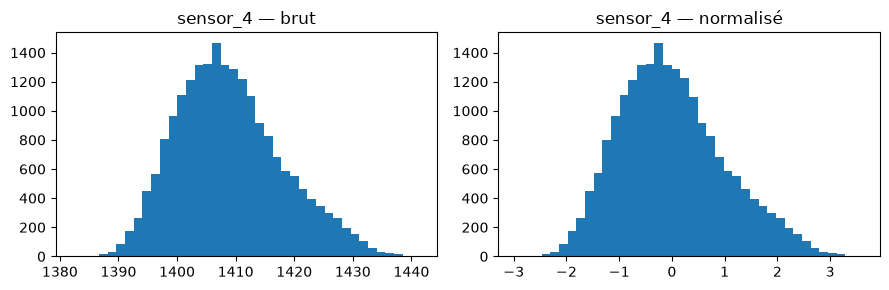

In [3]:
norm_stats = compute_norm_stats(train, selected_sensors)
train_normalized = normalize(train, selected_sensors, norm_stats)

example_sensor = "sensor_4"  # capteur à forte variance, cf. 02_eda_fd001.ipynb

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(train[example_sensor], bins=40)
axes[0].set_title(f"{example_sensor} — brut")
axes[1].hist(train_normalized[example_sensor], bins=40)
axes[1].set_title(f"{example_sensor} — normalisé")
fig.tight_layout()

**Ce que montre cette figure** : à gauche, `sensor_4` brut, centré autour d'une valeur physique
(~1400) avec une échelle qui lui est propre. À droite, le même capteur après normalisation :
même forme de distribution (la normalisation ne déforme pas les données, elle les recentre),
mais maintenant centrée sur 0 avec un écart-type de 1. C'est ce recentrage qui permet au modèle
de comparer des capteurs d'échelles très différentes (ex. température vs pression) sans qu'un
capteur ne domine artificiellement les autres à cause de sa seule échelle numérique.

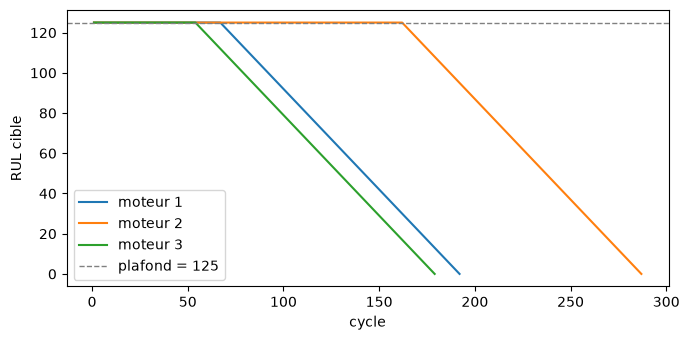

In [4]:
train_with_rul = add_piecewise_rul(train, cap=125)

fig, ax = plt.subplots(figsize=(7, 3.5))
for unit in [1, 2, 3]:  # quelques moteurs à durées de vie différentes
    unit_data = train_with_rul[train_with_rul["unit_number"] == unit]
    ax.plot(unit_data["time_cycles"], unit_data["RUL"], label=f"moteur {unit}")

ax.axhline(125, color="grey", linestyle="--", linewidth=1, label="plafond = 125")
ax.set_xlabel("cycle")
ax.set_ylabel("RUL cible")
ax.legend()
fig.tight_layout()

**Ce que montre cette figure** : chaque courbe est la cible RUL d'un moteur au fil de ses
cycles. Sans plafonnement, ce serait une droite qui descend de sa valeur de départ jusqu'à 0
(RUL = cycles restants avant panne). Ici, on voit clairement le plateau à 125 : en début de
vie, la cible reste constante à 125 malgré des dizaines de cycles qui passent, puis descend
linéairement une fois qu'on entre dans la fenêtre où la dégradation devient visible dans les
capteurs. C'est exactement le comportement attendu (Heimes 2008) : on n'attend pas du modèle
qu'il devine un RUL précis quand rien dans les capteurs ne distingue encore un moteur "neuf"
d'un moteur "en bon état depuis 50 cycles".